In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
# load directories
posttag_dir = Path('./Data/comment_sections/tagged/posttag')
ids_dir = Path('./Data/identified_videos/ids_applied')


# create list of subfolders
subfolders = [
    p for p in posttag_dir.iterdir()
    if p.is_dir()
]

In [3]:
# store results
all_results = []

# iterate through subfolders
for subfolder in subfolders:

    folder_name = subfolder.name

    # find corresponding id file
    ids_file = ids_dir / f'{folder_name}_outliers.csv'

    # handle exceptions
    if not ids_file.exists():
        print(
            f'WARNING: No ID file found for {folder_name}: '
            f'{ids_file}'
        )
        continue

    print(f'\nProcessing: {folder_name}')
    print(f'ID file: {ids_file}')


    # read data from id files
    ids_df = pd.read_csv(ids_file)

    ids_df['id'] = pd.to_numeric(
        ids_df['id'],
        errors='coerce'
    )

    # map play_count and video_id
    play_count_map = (
        ids_df
        .set_index('id')['play_count']
        .to_dict()
    )

    video_id_map = (
        ids_df
        .set_index('id')['video_id']
        .to_dict()
    )


    # find tagged data
    csv_files = list(subfolder.glob('*.csv'))

    for csv_file in csv_files:

        # extract id from file name
        numbers = re.findall(
            r'\d+',
            csv_file.stem
        )

        # handle exceptions
        if not numbers:
            print(
                f'  WARNING: Could not extract ID from '
                f'{csv_file.name}'
            )
            continue

        post_id = int(numbers[-1])


        # get play_count and video_id
        play_count = play_count_map.get(
            post_id,
            np.nan
        )

        video_id = video_id_map.get(
            post_id,
            np.nan
        )
        
        # handle exceptions
        if pd.isna(play_count):
            print(
                f'  WARNING: ID {post_id} not found '
                f'in {ids_file.name}'
            )


        # read tagged comment data
        df = pd.read_csv(csv_file)
        
        # handle exceptions
        if 'tag' not in df.columns:
            print(
                f'  WARNING: No 'tag' column in '
                f'{csv_file}'
            )
            continue

        if 'comment' not in df.columns:
            print(
                f'  WARNING: No 'comment' column in '
                f'{csv_file}'
            )
            continue


        # clean data
        # remove NaN comments
        df = df.dropna(
            subset=['comment']
        )
        
        # remove empty and whitespace-only comments
        df = df[
            df['comment']
            .astype(str)
            .str.strip()
            != ''
        ]


        # convert tags to numeric
        tags = pd.to_numeric(
            df['tag'],
            errors='coerce'
        )

        n_comments = len(tags)


        # calculate proportions
        if n_comments == 0:

            pro_phonp = 0
            anti_phonp = 0
            unclear = 0

        else:

            pro_phonp = (
                (tags == 0).sum()
                / n_comments
            )

            anti_phonp = (
                (tags == 1).sum()
                / n_comments
            )

            unclear = (
                tags.isna().sum()
                / n_comments
            )


        # store results
        all_results.append({
            'subfolder': folder_name,
            'post_id': post_id,
            'video_id': video_id,
            'play_count': play_count,

            'pro_phonp': pro_phonp,
            'anti_phonp': anti_phonp,
            'unclear': unclear,

            'n_comments': n_comments,
            'file': str(csv_file),
        })


Processing: ausunions
ID file: Data\identified_videos\ids_applied\ausunions_outliers.csv

Processing: onenationoz
ID file: Data\identified_videos\ids_applied\onenationoz_outliers.csv

Processing: paulinehansononenation
ID file: Data\identified_videos\ids_applied\paulinehansononenation_outliers.csv

Processing: weareunion
ID file: Data\identified_videos\ids_applied\weareunion_outliers.csv


In [8]:
# convert results to data frame
results = pd.DataFrame(all_results)

if results.empty:
    raise ValueError(
        'No valid tagged CSVs were found.'
    )


# sort results
results = results.sort_values(
    ['subfolder', 'play_count'],
    ascending=[True, False]
)


# save as csv
output_file = Path(
    './Output/posttag_tag_proportions.csv'
)

results.to_csv(
    output_file,
    index=False
)

print(
    f'\nSaved results to: {output_file}'
)


Saved results to: Output\posttag_tag_proportions.csv


Saved: Output\one_nation_pauline_hanson.png


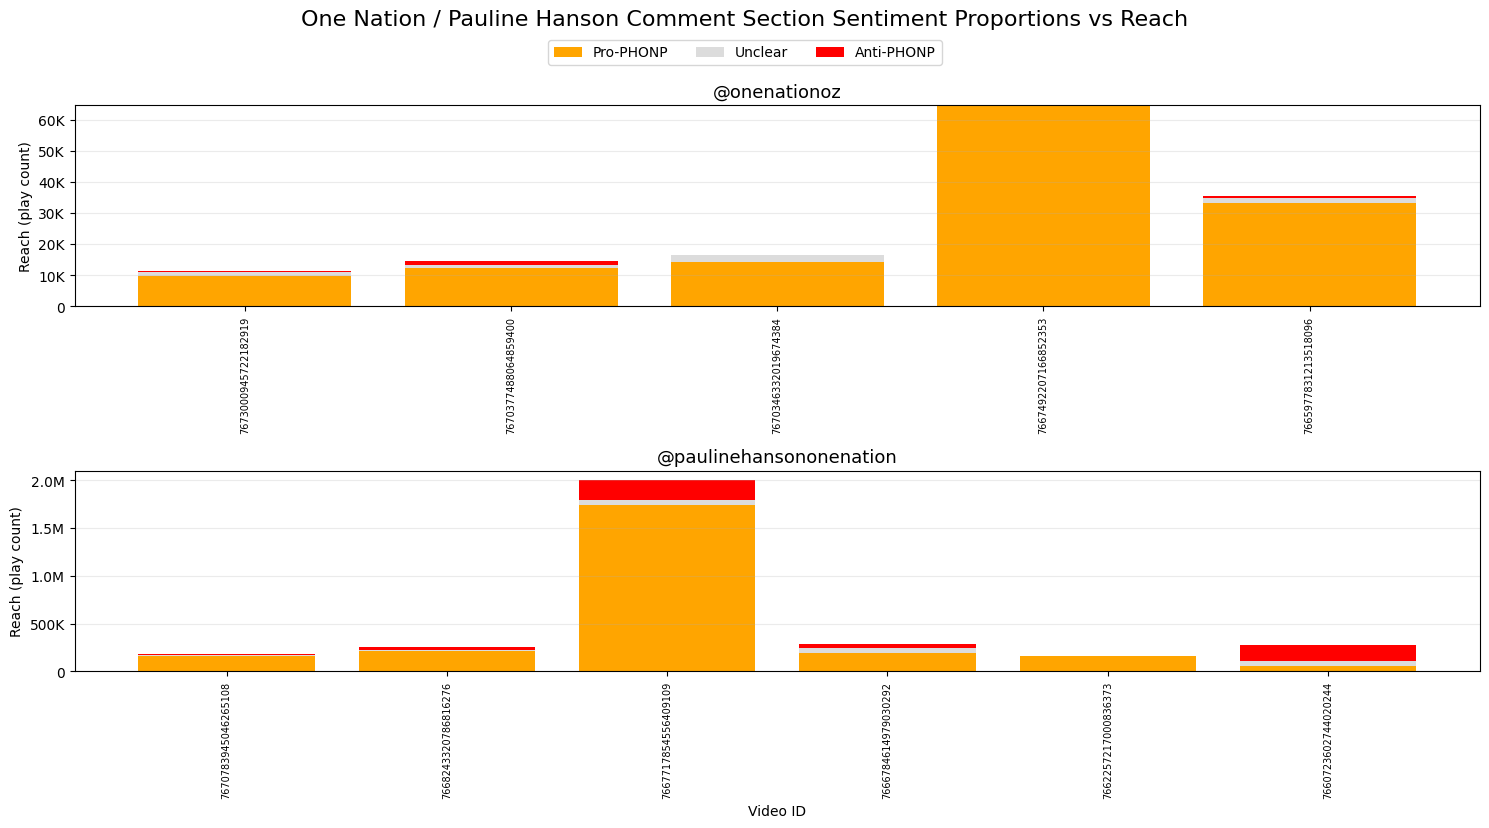

Saved: Output\australian_unions.png


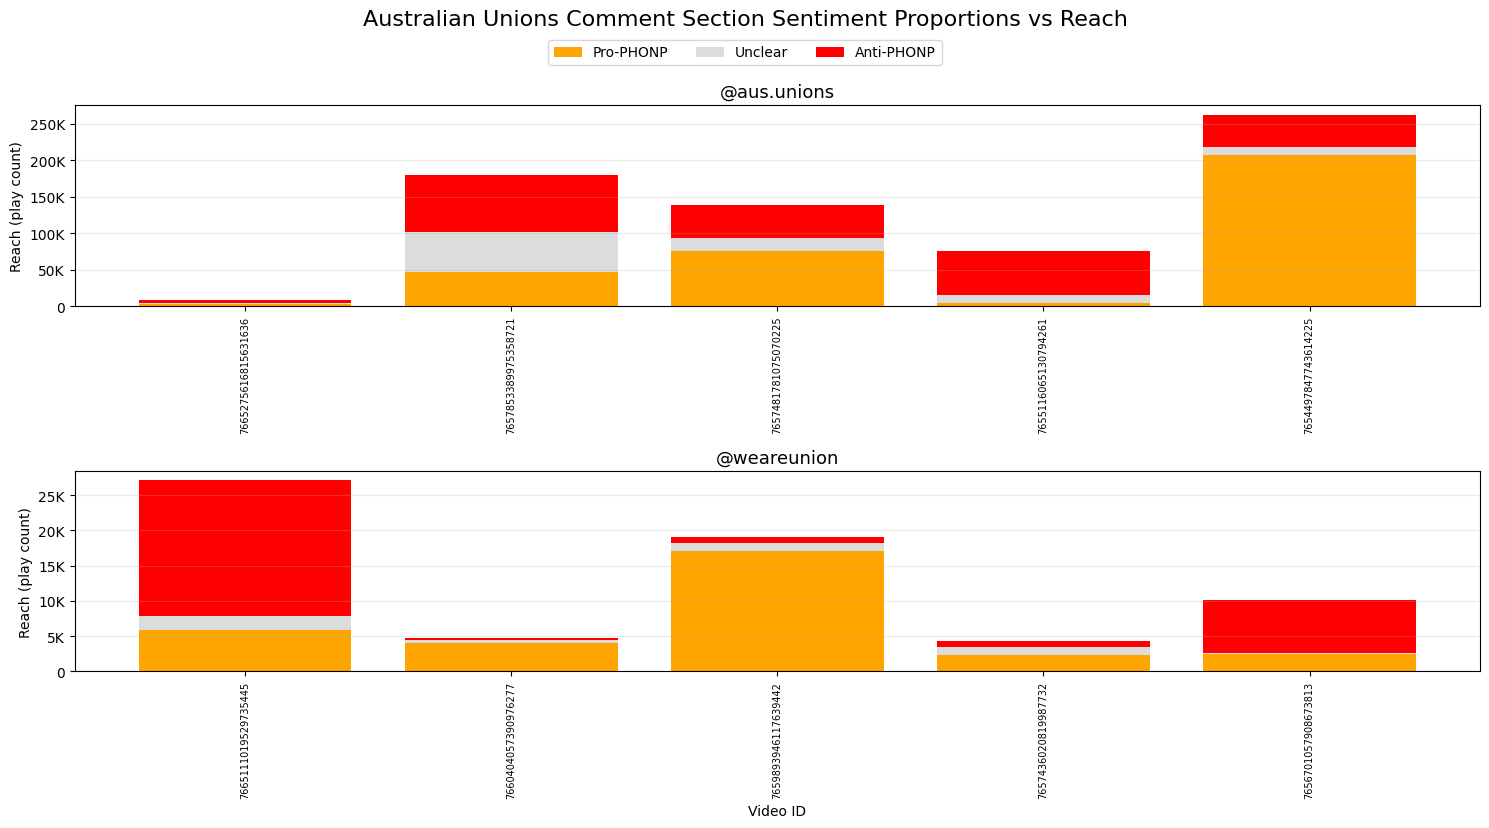

In [6]:
# visualisation

def format_play_count(x, pos):
    """
    Formats play count figures for improved visibility during visualisation.

    Parameters:
    x = tick value
    pos = index value of tick

    Example:
    - x >= 1,000,000 output to 1dp using suffix 'm' (e.g., 1100000 -> '1.1m')
    - 1,000 =< x < 1,000,000 output to 1dp using suffix 'k' (e.g., 1100 -> '1.1k')
    """
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x / 1_000:.0f}K'
    else:
        return f'{x:.0f}'


# initialise output dir

output_dir = Path('./Output')
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# intialise figure groups for output (@onenationoz + @paulinehansononenation, @ausunions + weareunion)

figure_groups = [
    {
        'folders': [
            'onenationoz',
            'paulinehansononenation'
        ],
        'titles': [
            '@onenationoz',
            '@paulinehansononenation'
        ],
        'filename': 'one_nation_pauline_hanson.png',
        'figure_title': 'One Nation / Pauline Hanson Comment Section Sentiment Proportions vs Reach'
    },
    {
        'folders': [
            'ausunions',
            'weareunion'
        ],
        'titles': [
            '@aus.unions',
            '@weareunion'
        ],
        'filename': 'australian_unions.png',
        'figure_title': 'Australian Unions Comment Section Sentiment Proportions vs Reach'
    }
]


# create 2x figures

for group in figure_groups:

    folders = group['folders']
    titles = group['titles']

    n_subplots = len(folders)

    fig, axes = plt.subplots(
        n_subplots,
        1,
        figsize=(
            15,
            8
        ),
        squeeze=False
    )

    axes = axes.flatten()

    # plot each subfolder
    # iterate through each subfolder
    for ax, folder, title in zip(
        axes,
        folders,
        titles
    ):

        subset = results[
            results['subfolder'] == folder
        ].copy()


        # sort by post_id
        subset = subset.sort_values(
            'post_id',
            ascending=True
        )

        x = np.arange(len(subset))

        play_count = (
            subset['play_count']
            .fillna(0)
            .values
        )


        # calculate bar heights
        pro_phonp_height = (
            play_count
            * subset['pro_phonp'].values
        )

        anti_phonp_height = (
            play_count
            * subset['anti_phonp'].values
        )

        unclear_height = (
            play_count
            * subset['unclear'].values
        )


        # stack bars
        ax.bar(
            x,
            pro_phonp_height,
            label='Pro-PHONP',
            color='orange'
        )

        ax.bar(
            x,
            unclear_height,
            bottom=pro_phonp_height,
            label='Unclear',
            color='gainsboro'
        )

        ax.bar(
            x,
            anti_phonp_height,
            bottom=(
                pro_phonp_height
                + unclear_height
            ),
            label='Anti-PHONP',
            color='red'
        )


        # set title + labels
        ax.set_title(
            title,
            fontsize=13
        )

        ax.set_ylabel(
            'Reach (play count)'
        )

        # apply format_play_count
        ax.yaxis.set_major_formatter(
            FuncFormatter(format_play_count)
        )
        
        ax.set_xticks(x)

        ax.set_xticklabels(
            subset['video_id'].astype(str),
            rotation=90,
            fontsize=7,
            ha='center'
        )

        ax.grid(
            axis='y',
            alpha=0.25
        )

    axes[-1].set_xlabel(
        'Video ID'
    )


    # created shared legend
    handles, labels = (
        axes[0].get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=3,
        bbox_to_anchor=(0.5, 1.0)
    )


    # apply subtitles
    fig.suptitle(
        group['figure_title'],
        fontsize=16,
        y=1.03
    )


    plt.tight_layout()


    # save fig
    output_path = output_dir / group['filename']

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches='tight'
    )

    print(
        f'Saved: {output_path}'
    )
    
    plt.show()

    plt.close(fig)